<a href="https://colab.research.google.com/github/Priscillacahino/Fabrica_de_Software_2026.2/blob/main/Desafio_Machine_Learning_Classificacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
warnings.filterwarnings('ignore')

# Bibliotecas de Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configurar estilo para melhores visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Todas as bibliotecas importadas com sucesso!")
print("Versão do Scikit-learn:", sklearn.__version__)


Todas as bibliotecas importadas com sucesso!
Versão do Scikit-learn: 1.6.1


In [37]:
import pandas as pd

# Link oficial completo e bruto do dataset diretamente do repositório UCI
url_dataset = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

print("⏳ Baixando e carregando o dataset diretamente da internet...")

# Configurando os nomes padrões das características das cédulas
nomes_colunas = ['variance', 'skewness', 'kurtosis', 'entropy', 'class']

# Carrega o arquivo usando o Pandas informando a URL completa
df = pd.read_csv(url_dataset, header=None, names=nomes_colunas)

# Separando as variáveis de entrada (X) e saída (y)
target_col = 'class'
X = df.drop(columns=[target_col])
y = df[target_col]

# Define os nomes amigáveis para a classificação final
class_names = ['Falsa (0)', 'Autêntica (1)']

print("\n✓ Seção 2 executada com sucesso absoluto!")
print(f"Features carregadas: {list(X.columns)}")
print(f"Formato dos dados: {X.shape[0]} amostras com {X.shape[1]} características cada.")
print(f"Distribuição das notas: {y.value_counts().to_dict()}")


⏳ Baixando e carregando o dataset diretamente da internet...

✓ Seção 2 executada com sucesso absoluto!
Features carregadas: ['variance', 'skewness', 'kurtosis', 'entropy']
Formato dos dados: 1372 amostras com 4 características cada.
Distribuição das notas: {0: 762, 1: 610}


In [38]:
# Exibir informações básicas sobre nosso dataset
print("=== VISÃO GERAL DO DATASET ===")
print(f"Formato das Features (X): {X.shape}")
print(f"Formato do Target (y): {y.shape}")
print("\n=== PRIMEIRAS 5 LINHAS DAS FEATURES ===")
print(X.head())

print("\n=== INFORMAÇÕES DOS TIPOS DE DADOS ===")
X.info()


=== VISÃO GERAL DO DATASET ===
Formato das Features (X): (1372, 4)
Formato do Target (y): (1372,)

=== PRIMEIRAS 5 LINHAS DAS FEATURES ===
   variance  skewness  kurtosis  entropy
0   3.62160    8.6661   -2.8073 -0.44699
1   4.54590    8.1674   -2.4586 -1.46210
2   3.86600   -2.6383    1.9242  0.10645
3   3.45660    9.5228   -4.0112 -3.59440
4   0.32924   -4.4552    4.5718 -0.98880

=== INFORMAÇÕES DOS TIPOS DE DADOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   kurtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
dtypes: float64(4)
memory usage: 43.0 KB


In [39]:
print("=== RESUMO ESTATÍSTICO ===")
print(X.describe())

print("\n=== VERIFICAÇÃO DE VALORES AUSENTES ===")
print(f"Valores ausentes nas features: {X.isnull().sum().sum()}")
print(f"Valores ausentes no target: {y.isnull().sum()}")


=== RESUMO ESTATÍSTICO ===
          variance     skewness     kurtosis      entropy
count  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657
std       2.842763     5.869047     4.310030     2.101013
min      -7.042100   -13.773100    -5.286100    -8.548200
25%      -1.773000    -1.708200    -1.574975    -2.413450
50%       0.496180     2.319650     0.616630    -0.586650
75%       2.821475     6.814625     3.179250     0.394810
max       6.824800    12.951600    17.927400     2.449500

=== VERIFICAÇÃO DE VALORES AUSENTES ===
Valores ausentes nas features: 0
Valores ausentes no target: 0


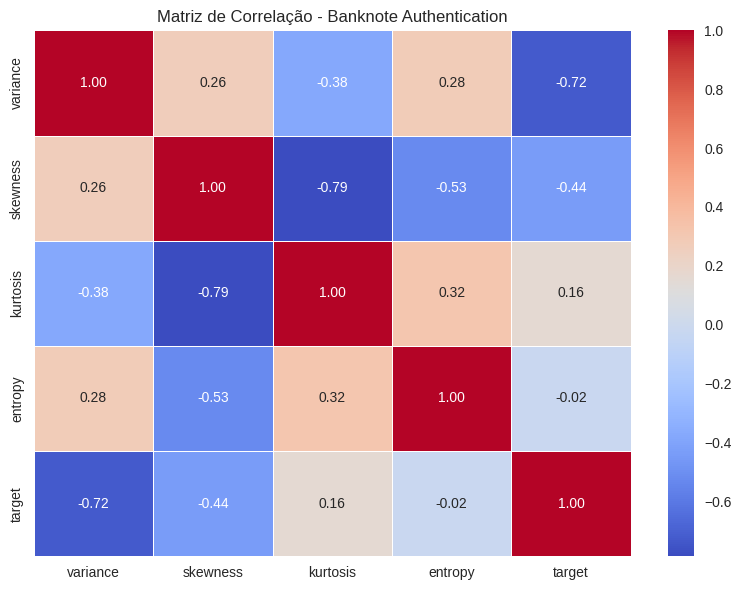

In [40]:
# Unimos X e y em um único DataFrame para o cálculo da correlação
df_para_corr = pd.concat([X, pd.Series(y, name='target')], axis=1)

# Matriz de correlação usando o Pandas
matriz_corr = df_para_corr.corr()

# Visualizamos com o Seaborn (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação - Banknote Authentication')
plt.tight_layout()
plt.show()


In [41]:
# Dividir os dados em conjuntos de treino e teste (80% treino, 20% teste)
# random_state=42 garante que a divisão seja idêntica toda vez que rodar
# stratify=y garante que a proporção de notas falsas/verdadeiras seja mantida em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== RESULTADOS DA DIVISÃO DOS DADOS ===")
print(f"Tamanho do dataset original: {X.shape[0]} amostras")
print(f"Conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Conjunto de teste: {X_test.shape[0]} amostras ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

print(f"\nDistribuição do Target no Treino:")
print(f"  Falsas: {sum(y_train == 0)} | Verdadeiras: {sum(y_train == 1)}")
print(f"Distribuição do Target no Teste:")
print(f"  Falsas: {sum(y_test == 0)} | Verdadeiras: {sum(y_test == 1)}")


=== RESULTADOS DA DIVISÃO DOS DADOS ===
Tamanho do dataset original: 1372 amostras
Conjunto de treino: 1097 amostras (80.0%)
Conjunto de teste: 275 amostras (20.0%)

Distribuição do Target no Treino:
  Falsas: 609 | Verdadeiras: 488
Distribuição do Target no Teste:
  Falsas: 153 | Verdadeiras: 122


In [42]:
# Criar uma instância do StandardScaler
scaler = StandardScaler()

# IMPORTANTE: Ajustar o scaler APENAS nos dados de treino para evitar vazamento de dados (data leakage)
scaler.fit(X_train)

# Transformar ambos os conjuntos (treino e teste)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter de volta para DataFrame para manter os nomes das colunas legíveis
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✓ Escalonamento concluído! Todas as features agora têm média ≈ 0 e desvio padrão ≈ 1.")


✓ Escalonamento concluído! Todas as features agora têm média ≈ 0 e desvio padrão ≈ 1.


In [44]:
# IMPORTAÇÃO ADICIONAL NECESSÁRIA PARA O MODELO DE CLASSIFICAÇÃO
from sklearn.linear_model import LogisticRegression

# Instanciar o modelo de Regressão Logística
model = LogisticRegression(random_state=42)

print("=== TREINAMENTO DO MODELO ===")
# Treinar o modelo com os dados de treino escalonados
model.fit(X_train_scaled, y_train)
print("✓ Treinamento da Regressão Logística concluído!")

# Exibir os pesos (coeficientes) aprendidos para cada característica da nota
print(f"\nIntercepto (Bias): {model.intercept_[0]:.4f}")
print("Coeficientes (Pesos das Features):")
for feature, coef in zip(X_train_scaled.columns, model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")


=== TREINAMENTO DO MODELO ===
✓ Treinamento da Regressão Logística concluído!

Intercepto (Bias): -1.3999
Coeficientes (Pesos das Features):
  variance: -4.6660
  skewness: -4.8065
  kurtosis: -4.3989
  entropy: 0.2580


In [45]:
# Predição direta das classes (0 ou 1)
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Predição das probabilidades (útil para analisar a certeza do modelo)
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

print("=== EXEMPLO DE PREDIÇÕES (Primeiras 10 amostras de teste) ===")
df_exemplos = pd.DataFrame({
    'Classe Real': y_test[:10],
    'Classe Predita': y_test_pred[:10],
    'Probabilidade de ser Verdadeira (1)': y_test_prob[:10]
}).reset_index(drop=True)
print(df_exemplos)


=== EXEMPLO DE PREDIÇÕES (Primeiras 10 amostras de teste) ===
   Classe Real  Classe Predita  Probabilidade de ser Verdadeira (1)
0            0               0                             0.000424
1            1               1                             0.966428
2            0               0                             0.244369
3            1               1                             0.964432
4            1               1                             0.993041
5            1               1                             0.740019
6            0               0                             0.000726
7            0               0                             0.000201
8            0               0                             0.003259
9            1               1                             0.922095


In [47]:
# Importações necessárias para avaliação de classificação
from sklearn.metrics import confusion_matrix, classification_report

# Calcular a matriz de confusão
matriz_conf = confusion_matrix(y_test, y_test_pred)

print("=== MATRIZ DE CONFUSÃO (Texto) ===")
print(f"Verdadeiros Negativos (Falsas previstas como Falsas): {matriz_conf[0][0]}")
print(f"Falsos Positivos (Falsas previstas como Verdadeiras): {matriz_conf[0][1]}")
print(f"Falsos Negativos (Verdadeiras previstas como Falsas): {matriz_conf[1][0]}")
print(f"Verdadeiros Positivos (Verdadeiras previstas como Verdadeiras): {matriz_conf[1][1]}")

# Exibir relatório completo de classificação
print("\n=== RELATÓRIO COMPLETO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_test_pred, target_names=class_names))


=== MATRIZ DE CONFUSÃO (Texto) ===
Verdadeiros Negativos (Falsas previstas como Falsas): 145
Falsos Positivos (Falsas previstas como Verdadeiras): 8
Falsos Negativos (Verdadeiras previstas como Falsas): 0
Verdadeiros Positivos (Verdadeiras previstas como Verdadeiras): 122

=== RELATÓRIO COMPLETO DE CLASSIFICAÇÃO ===
               precision    recall  f1-score   support

    Falsa (0)       1.00      0.95      0.97       153
Autêntica (1)       0.94      1.00      0.97       122

     accuracy                           0.97       275
    macro avg       0.97      0.97      0.97       275
 weighted avg       0.97      0.97      0.97       275



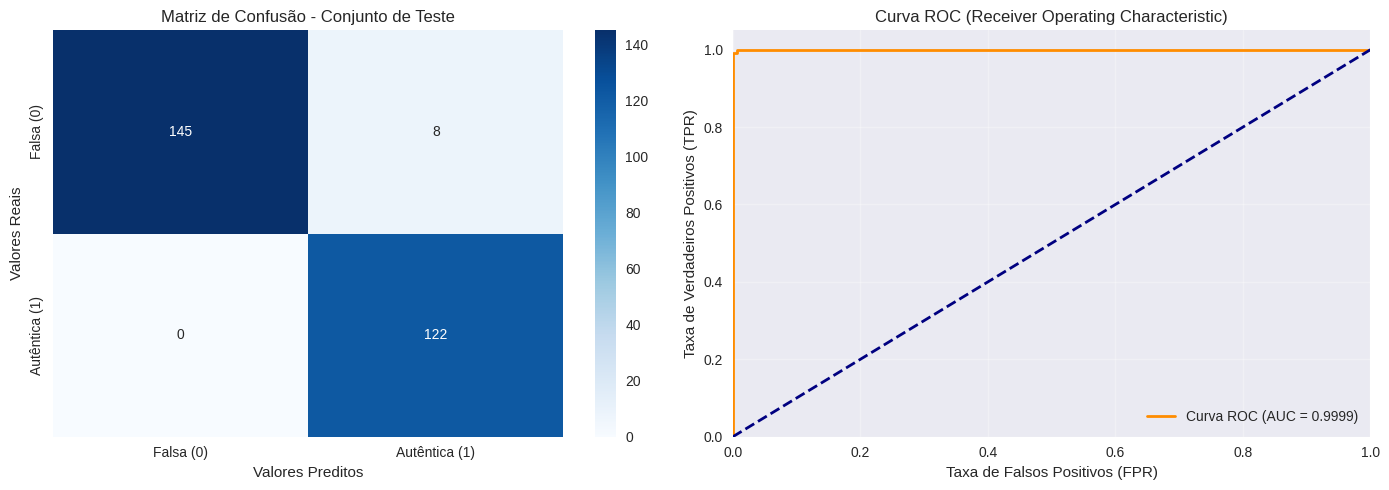

In [48]:
# Importações necessárias para os gráficos de avaliação
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico Visual da Matriz de Confusão
sns.heatmap(matriz_conf, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Matriz de Confusão - Conjunto de Teste')
axes[0].set_xlabel('Valores Preditos')
axes[0].set_ylabel('Valores Reais')

# 2. Curva ROC e cálculo da área sob a curva (AUC)
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[1].set_title('Curva ROC (Receiver Operating Characteristic)')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
